In [3]:
import pandas as pd

df = pd.read_csv("framingham_data_new_updated.csv")
print(df.shape)
df.head()

(4699, 13)


,id,sex,sbp,dbp,scl,age,bmi,month,followup,chdfate,chol_range,bmic,BP_range
0,2642,Male,120,80,267.0,55,25.0,8,18,1,high,overweight,High BP Stage 1
1,4627,Male,130,78,192.0,53,28.4,12,35,1,desirable,overweight,High BP Stage 1
2,2568,Male,144,90,207.0,61,25.1,8,109,1,borderline,overweight,High BP Stage 2
3,4192,Male,92,66,231.0,48,26.2,11,147,1,borderline,overweight,Normal BP
4,3977,Male,162,98,271.0,39,28.4,11,169,1,high,overweight,High BP Stage 2


In [7]:
count = 0
total = 0

for i in range(len(df)):
    if df.loc[i, "sbp"] > 140:
        total += 1
        if df.loc[i, "chdfate"] == 1:
            count += 1

print(f"People with high blood pressure: {count}, People with CHD after 10 years: {total}")

People with high blood pressure: 547, People with CHD after 10 years: 1319


In [ ]:
#conditional logic to describe the mean systolic blood pressure
bp = df["sbp"].mean()

if bp < 120:
    print("Average BP is normal")
elif bp < 140:
    print("Average BP is elevated")
else:
    print("Average BP is high")

Average BP is elevated


In [11]:
#returns proportion of people with CHD above a BP threshold
def chd_rate(bp_threshold):
    subset = df[df["sbp"] > bp_threshold]
    return subset["chdfate"].mean()

print(f"Proportion of people with CHD above BP threshold of 130:", chd_rate(130))
print(f"Proportion of people with CHD above BP threshold of 150:",chd_rate(150))

Proportion of people with CHD above BP threshold of 130: 0.3871879415920867
Proportion of people with CHD above BP threshold of 150: 0.4299634591961023


In [ ]:
#numpy array work
import numpy as np

bp_array = np.array(df["sbp"])

print(np.mean(bp_array))  # vectorized
print(bp_array[bp_array > 140])  # boolean mask
print(bp_array[0])  # indexing

132.7665460736327
[144 162 212 ... 152 156 142]
120


In [19]:
#dictionary
results = {}

thresholds = [120, 130, 140, 150]

for t in thresholds:
    subset = df[df["sbp"] > t]  # define subset INSIDE loop
    results[t] = float(subset["chdfate"].mean())

print(results)

# find highest
max_key = max(results, key=results.get)
print("Highest CHD rate at BP >", max_key)

{120: 0.3593648736228127, 130: 0.3871879415920867, 140: 0.41470811220621684, 150: 0.4299634591961023}
Highest CHD rate at BP > 150


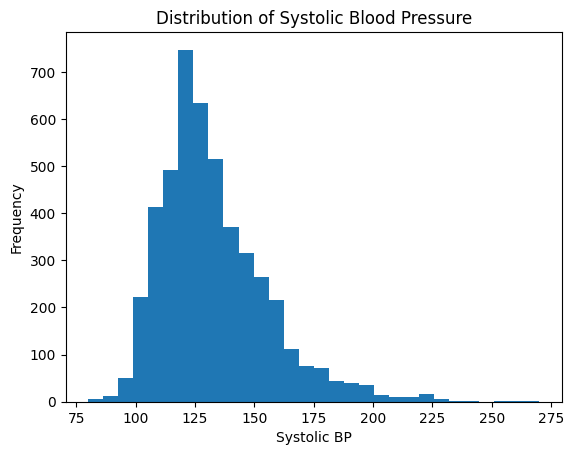

In [ ]:
#histogram
import matplotlib.pyplot as plt

plt.hist(df["sbp"], bins=30)
plt.title("Distribution of Systolic Blood Pressure")
plt.xlabel("Systolic BP")
plt.ylabel("Frequency")
plt.show()

This graph is rougly normal (Gaussian), although it is skewed right, which you can see from the tail on the right side.

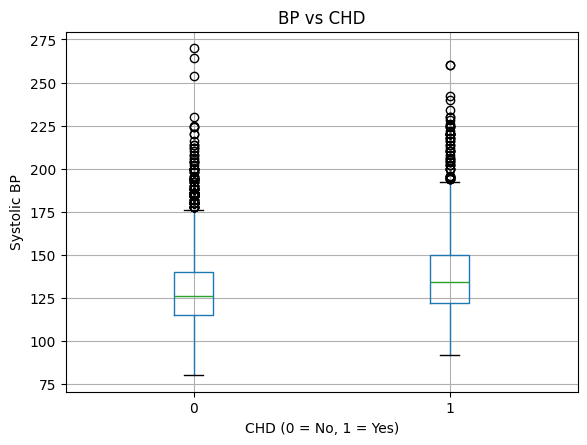

In [16]:
#boxplot
df.boxplot(column="sbp", by="chdfate")
plt.title("BP vs CHD")
plt.suptitle("")
plt.xlabel("CHD (0 = No, 1 = Yes)")
plt.ylabel("Systolic BP")
plt.show()

I used a box plot to compare the distribution of systolic blood pressure between individuals with and without CHD. I chose a boxplot because this allows us to see differences in median, spread, and outliers across the two groups.

In [20]:
#linear regression
import numpy as np

x = np.array(df["sbp"])
y = np.array(df["chdfate"])

# fit line: y = mx + b
slope, intercept = np.polyfit(x, y, 1)

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 0.003668814649498661
Intercept: -0.1736248979320568


The regression shows a positive slope, indicating that higher systolic blood pressure is associated with higher CHD risk, although the R² value suggests the relationship is relatively weak.